In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

In [51]:
df = pd.read_csv('./2025_Airbnb_NYC_listings.csv')
df.shape

(22308, 73)

# 필요 컬럼 목록 만들기

In [52]:
price_policy_cols = [
    'price',
    'minimum_nights',
    'maximum_nights',
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_maximum_nights',
    'maximum_maximum_nights',
    'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm',
    'has_availability',
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_365',
    'availability_eoy',
    'instant_bookable'
]

### 1. 결측치 탐색 및 처리

In [88]:
fake_null = ['NaN', 'None', 'none', 'NULL', 'null', 'N/A', 'na', '']

In [89]:
df[price_policy_cols].isin(fake_null).sum()

price                     0
minimum_nights            0
maximum_nights            0
minimum_minimum_nights    0
maximum_minimum_nights    0
minimum_maximum_nights    0
maximum_maximum_nights    0
minimum_nights_avg_ntm    0
maximum_nights_avg_ntm    0
has_availability          0
availability_30           0
availability_60           0
availability_90           0
availability_365          0
availability_eoy          0
instant_bookable          0
price_log1p               0
dtype: int64

In [53]:
missing_ratio_price = (df[price_policy_cols].isna().mean().sort_values(ascending=False) * 100)
missing_ratio_price

has_availability         1.10
price                    0.00
maximum_nights           0.00
minimum_nights           0.00
maximum_minimum_nights   0.00
minimum_maximum_nights   0.00
maximum_maximum_nights   0.00
minimum_minimum_nights   0.00
minimum_nights_avg_ntm   0.00
maximum_nights_avg_ntm   0.00
availability_30          0.00
availability_60          0.00
availability_90          0.00
availability_365         0.00
availability_eoy         0.00
instant_bookable         0.00
dtype: float64

In [54]:
df[price_policy_cols].isna().sum()

price                       0
minimum_nights              0
maximum_nights              0
minimum_minimum_nights      0
maximum_minimum_nights      0
minimum_maximum_nights      0
maximum_maximum_nights      0
minimum_nights_avg_ntm      0
maximum_nights_avg_ntm      0
has_availability          246
availability_30             0
availability_60             0
availability_90             0
availability_365            0
availability_eoy            0
instant_bookable            0
dtype: int64

In [55]:
df['has_availability'].value_counts()

has_availability
t    22062
Name: count, dtype: int64

In [56]:
df['has_availability'] = df['has_availability'].fillna('f')

# has_availability는 예약 가능 여부를 나타내는 변수이다.
# 결측치를 최빈값(t)으로 대체할 경우 실제 예약 불가 상태일 가능성을 무시하고
# 예약 가능 숙소로 학습될 위험이 있다.
# 따라서 보수적 접근을 적용하여 결측치는 'f' (예약 불가)로 대체하였다.
# 데이터 타입 변환 필요 -> boolean으로!
df['has_availability'].value_counts()

has_availability
t    22062
f      246
Name: count, dtype: int64

### 2.이상치 탐색 및 처리

In [57]:
df[df['minimum_nights'] > df['maximum_nights']]

,Unnamed: 0,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month


In [58]:
df[df['minimum_nights'] <= 0]

,Unnamed: 0,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month


In [59]:
df[df['maximum_nights'] <= 0]

,Unnamed: 0,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month


In [60]:
df[df['availability_30'] > 30]
df[df['availability_60'] > 60]
df[df['availability_90'] > 90]
df[df['availability_365'] > 365]

,Unnamed: 0,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month


In [61]:
df[
    (df['availability_30'] > df['availability_60']) |
    (df['availability_60'] > df['availability_90']) |
    (df['availability_90'] > df['availability_365'])
]

,Unnamed: 0,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month


In [62]:
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# price는 통화기호($)와 천단위 구분자(,)가 포함된 문자열 형태이므로
# 이를 제거한 후 float 타입으로 변환하였다.

In [63]:
df[df['price'] <= 0]

,Unnamed: 0,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month


In [64]:
df['price'].describe()

count   22308.00
mean      213.84
std       427.60
min         7.00
25%        85.00
50%       140.00
75%       240.00
max     20000.00
Name: price, dtype: float64

In [65]:
print("500달러 이상:", len(df[df["price"] >= 500]) / len(df['price']) * 100)        #가격이 500달러 이상인 숙소는 전체의 6% 정도
print("1000달러 이상:", len(df[df["price"] >= 1000]) / len(df['price']) * 100)      #가격이 1000달러 이상인 숙소는 전체의 1.5% 정도
print("2000달러 이상:", len(df[df["price"] >= 2000]) / len(df['price']) * 100)      #가격이 2000달러 이상인 숙소는 전체의 0.4% 정도
print("5000달러 이상:", len(df[df["price"] >= 5000]) / len(df['price']) * 100)      #가격이 5000달러 이상인 숙소는 전체의 0.09% 정도
print("10000달러 이상:", len(df[df["price"] >= 10000]) / len(df['price']) * 100)    #가격이 10000달러 이상인 숙소는 전체의 0.04% 정도
print("전체 숙소 수:", len(df['price']))

500달러 이상: 5.899228976152053
1000달러 이상: 1.4434283665052896
2000달러 이상: 0.38999462076385155
5000달러 이상: 0.08517123901739286
10000달러 이상: 0.04930966469428008
전체 숙소 수: 22308


In [66]:
df["price_log1p"] = np.log1p(df["price"])  # log(1+Fare)
df["price_log1p"]

0       5.30
1       4.42
2       6.64
3       4.94
4       4.88
        ... 
22303   4.29
22304   4.08
22305   5.70
22306   5.30
22307   4.08
Name: price_log1p, Length: 22308, dtype: float64

In [67]:
price_policy_cols.append('price_log1p')

In [68]:
df[price_policy_cols].dtypes

price                     float64
minimum_nights              int64
maximum_nights              int64
minimum_minimum_nights    float64
maximum_minimum_nights    float64
minimum_maximum_nights    float64
maximum_maximum_nights    float64
minimum_nights_avg_ntm    float64
maximum_nights_avg_ntm    float64
has_availability              str
availability_30             int64
availability_60             int64
availability_90             int64
availability_365            int64
availability_eoy            int64
instant_bookable              str
price_log1p               float64
dtype: object

### 3.데이터 타입 변환

In [69]:
df['has_availability'] = df['has_availability'].map({'t': True, 'f': False}).astype(int)
df['instant_bookable'] = df['instant_bookable'].map({'t': True, 'f': False}).astype(int)
print(f'Dtype: {df["has_availability"].dtype}, {df["instant_bookable"].dtype}')

Dtype: int64, int64


### 4. EDA 시각화

<Axes: xlabel='price', ylabel='Count'>

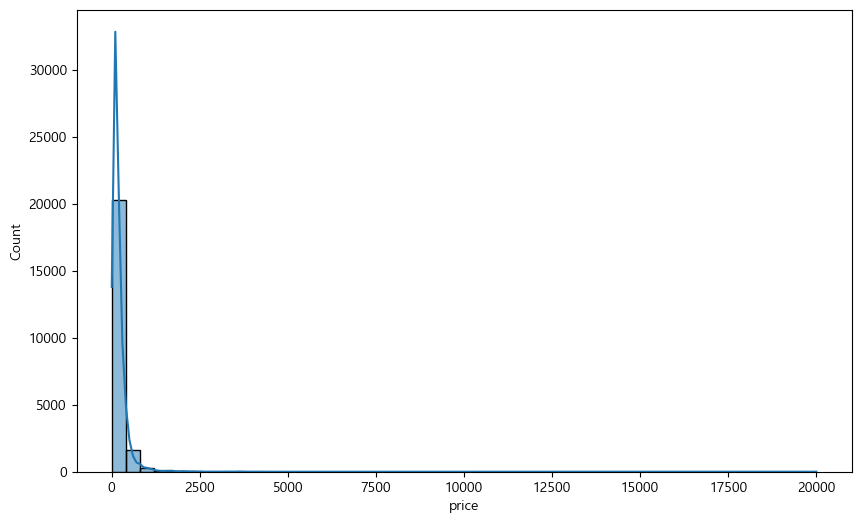

In [74]:
#price
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)

<Axes: xlabel='price_log1p', ylabel='Count'>

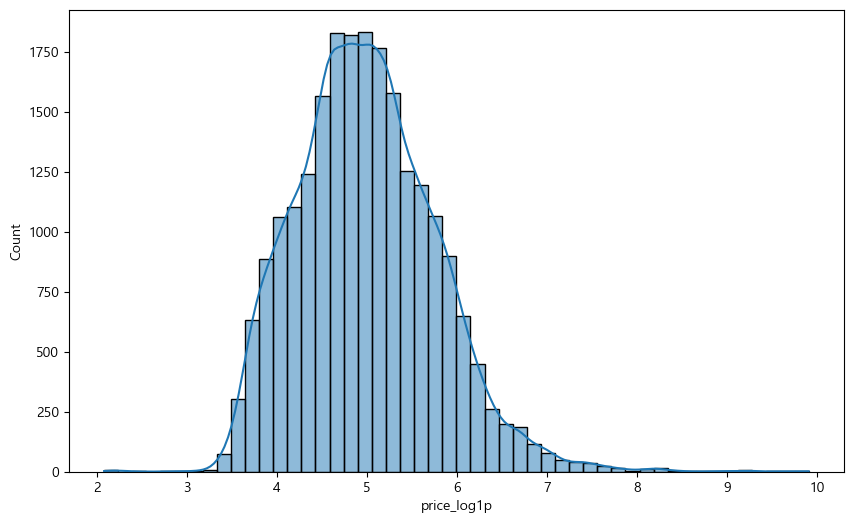

In [75]:
#price_log1p
plt.figure(figsize=(10, 6))
sns.histplot(df['price_log1p'], bins=50, kde=True)

<Axes: xlabel='minimum_nights', ylabel='Count'>

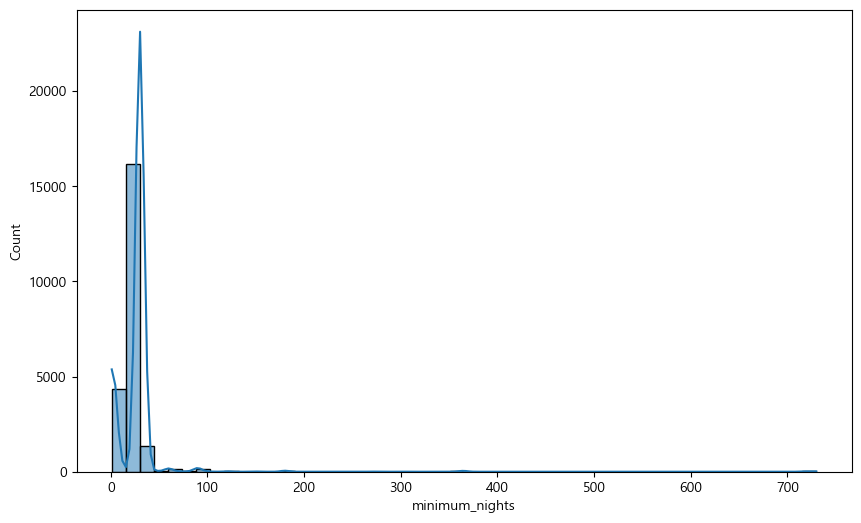

In [76]:
#minimum_nights
plt.figure(figsize=(10, 6))
sns.histplot(df['minimum_nights'], bins=50, kde=True)

<Axes: xlabel='maximum_nights', ylabel='Count'>

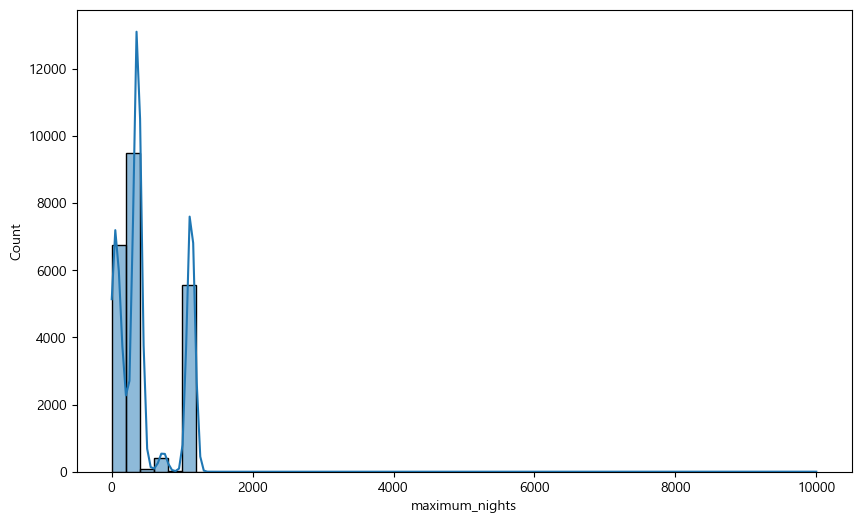

In [78]:
#maximum_nights
plt.figure(figsize=(10, 6))
sns.histplot(df['maximum_nights'], bins=50, kde=True)

In [85]:
df['availability_rate_30'] = (df['availability_30'] / 30)  #30일 기준으로 예약 가능 일수를 비율로 계산 -> 0~1 사이 값으로 반환
df['availability_rate_60'] = (df['availability_60'] / 60)
df['availability_rate_90'] = (df['availability_90'] / 90)
df['availability_rate_365'] = (df['availability_365'] / 365)

In [87]:
df[['availability_30','availability_60','availability_90','availability_365',
    'availability_rate_30','availability_rate_60','availability_rate_90','availability_rate_365']].describe()

,availability_30,availability_60,availability_90,availability_365,availability_rate_30,availability_rate_60,availability_rate_90,availability_rate_365
count,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00,22308.00
mean,0.00,0.60,0.64,0.66,0.00,0.01,0.01,0.00
std,0.00,0.40,0.37,0.31,0.00,0.01,0.00,0.00
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.20,0.32,0.41,0.00,0.00,0.00,0.00
50%,0.00,0.72,0.73,0.74,0.00,0.01,0.01,0.00
75%,0.00,0.98,0.99,0.96,0.00,0.02,0.01,0.00
max,0.00,1.00,1.00,1.00,0.00,0.02,0.01,0.00


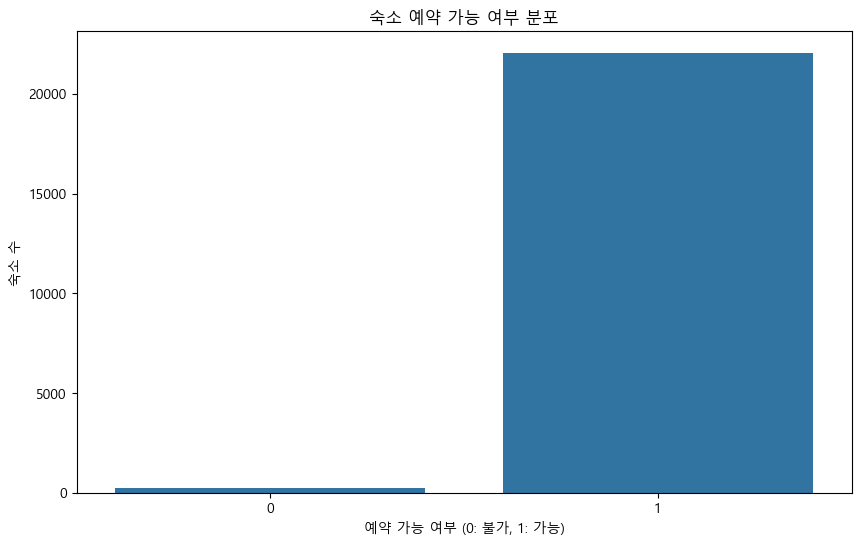

In [95]:
plt.figure(figsize=(10, 6))
sns.countplot(x='has_availability', data=df)
plt.title('숙소 예약 가능 여부 분포')
plt.xlabel('예약 가능 여부 (0: 불가, 1: 가능)')
plt.ylabel('숙소 수')
plt.show()

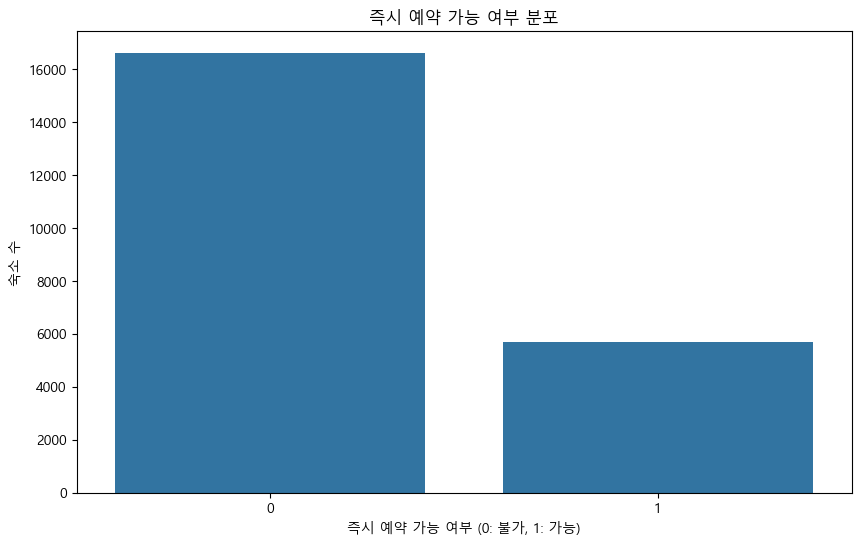

In [96]:
plt.figure(figsize=(10, 6))
sns.countplot(x='instant_bookable', data=df)
plt.title('즉시 예약 가능 여부 분포')
plt.xlabel('즉시 예약 가능 여부 (0: 불가, 1: 가능)')
plt.ylabel('숙소 수')
plt.show()

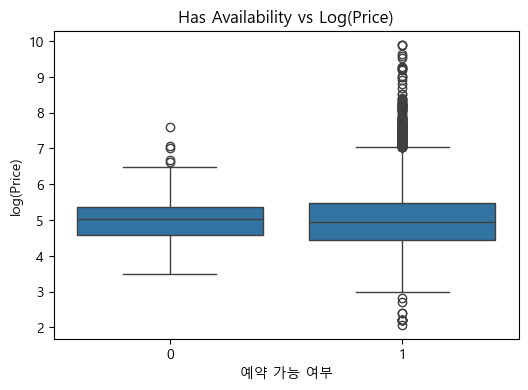

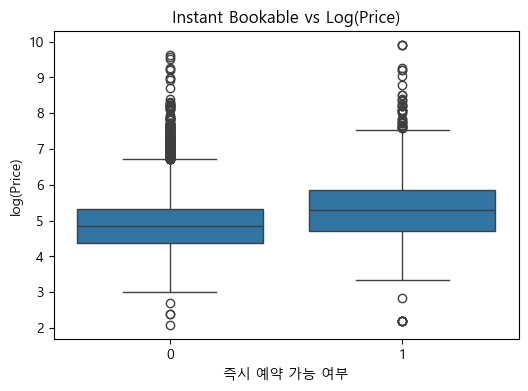

In [97]:
# has_availability별 price_log1p 분포
plt.figure(figsize=(6,4))
sns.boxplot(x='has_availability', y='price_log1p', data=df)
plt.title('Has Availability vs Log(Price)')
plt.xlabel('예약 가능 여부')
plt.ylabel('log(Price)')
plt.show()

# instant_bookable별 price_log1p 분포
plt.figure(figsize=(6,4))
sns.boxplot(x='instant_bookable', y='price_log1p', data=df)
plt.title('Instant Bookable vs Log(Price)')
plt.xlabel('즉시 예약 가능 여부')
plt.ylabel('log(Price)')
plt.show()